# 05 Evaluation

ขั้นตอนนี้ประเมินค่าทำนายจากขั้น 04 บนช่วง test (เดือนฐาน t ตั้งแต่ 2019-01) ตาม Scope หัวข้อ 13–14 และตอบ RQ1–RQ4

ลำดับงาน:
1. เลือก "โมเดลที่ดีที่สุด" ของแต่ละกลุ่มและ horizon จาก MAE ช่วง **validation** ก่อนเปิดผล test
2. คำนวณ MAE, RMSE และ Directional Accuracy ช่วง test
3. ทดสอบการเปรียบเทียบหลัก 3 ข้อที่ h=3 ของกลุ่ม 318 และ 402 ด้วย Diebold–Mariano แบบ HLN และปรับ p-value ด้วย Holm (6 การทดสอบ)
4. Alert layer: precision, recall และ F1 ของ High Risk โดยใช้ threshold ราย origin
5. ผลเชิงสำรวจ: sanity check กลุ่ม 100, sensitivity ของ cutoff วันที่ 24 และเส้นความแม่นตาม horizon (RQ4ก)

กฎที่ใช้: ห้ามเปลี่ยนโมเดล, feature, alpha หรือ threshold หลังเห็นผลในขั้นนี้

In [1]:
from __future__ import annotations
import hashlib, json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats
from statsmodels.stats.multitest import multipletests

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'PROJECT_SCOPE.md').exists())
METRICS_DIR, FIGURES_DIR = ROOT / 'logs/metrics', ROOT / 'reports/figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PRIMARY_H, MAIN_GROUPS, SANITY_GROUP = 3, ['318', '402'], '100'
GROUP_LABEL = {'100': 'Fuel (100)', '318': 'Fertilizer (318)', '402': 'Dairy (402)'}
COLORS = {'100': '#eb6834', '318': '#2a78d6', '402': '#1baf7a'}   # dataviz reference palette, fixed per group
INK, MUTED = '#2b2b2b', '#8a8a85'
ALPHA_WARN = 0.10

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''): digest.update(chunk)
    return digest.hexdigest()

run = pd.read_csv(METRICS_DIR / '04_run_manifest.csv')
pred_path = ROOT / run.loc[0, 'file']
assert sha256(pred_path) == run.loc[0, 'sha256'], '04_predictions.csv ไม่ตรงกับ manifest ของขั้น 04'
pred = pd.read_csv(pred_path, dtype={'commodity_code': str, 'feature_set': str},
                   parse_dates=['month_ce', 'forecast_origin'])
pred['series'] = pred.model + '/' + pred.feature_set
pred['error'] = pred.y_pred - pred.y_true
val, test = pred[pred.split == 'validation'], pred[pred.split == 'test']
print(f"ค่าทำนาย {len(pred):,} แถว; validation {len(val):,}, test {len(test):,}; series {pred.series.nunique()}")

ค่าทำนาย 28,560 แถว; validation 10,080, test 18,480; series 14


## 1. เลือกโมเดลที่ดีที่สุดจาก validation

สำหรับแต่ละ (กลุ่ม, h) เลือก series (โมเดล/feature set) ที่ MAE ช่วง validation ต่ำสุด โดยไม่รวม No-change เพราะ No-change เป็นตัวเทียบ การเลือกนี้ไม่ใช้ข้อมูลช่วง test

In [2]:
val_mae = val.groupby(['commodity_code', 'horizon', 'series']).error.apply(lambda e: e.abs().mean()).rename('validation_mae').reset_index()
best = (val_mae[val_mae.series != 'no_change/none'].sort_values(['commodity_code', 'horizon', 'validation_mae'])
        .groupby(['commodity_code', 'horizon']).head(1).reset_index(drop=True))
best.to_csv(METRICS_DIR / '05_best_model_by_validation.csv', index=False)
BEST = {(r.commodity_code, r.horizon): r.series for r in best.itertuples()}
display(best.pivot_table(index='horizon', columns='commodity_code', values='series', aggfunc='first'))

commodity_code,100,318,402
horizon,,,
2,ridge/3,ridge/3,arima/none
3,ridge/3,ridge/3,ridge/3-cutoff24
4,ridge/3,ridge/3,arima/none
5,ridge/3,ridge/3,arima/none
6,ridge/3,ridge/3,arima/none


## 2. Metric ช่วง test

- **MAE** เป็น metric หลัก **RMSE** เป็น metric รอง
- **Directional Accuracy (DA):** สัดส่วนเดือนที่ทายทิศทางถูก โดยนิยามขาขึ้นเป็น y > 0
- **DA baseline:** ทายทิศทางที่เกิดบ่อยที่สุดใน training set ของ origin นั้น (`train_up_share > 0.5`)
- **No-change:** ทำนาย 0 ทุกเดือน จึงทายว่า "ไม่ขึ้น" เสมอ

In [3]:
def summarize(frame):
    up_true = frame.y_true > 0
    return pd.Series({
        'n': len(frame), 'MAE': frame.error.abs().mean(), 'RMSE': np.sqrt((frame.error ** 2).mean()),
        'DA': ((frame.y_pred > 0) == up_true).mean(),
        'DA_baseline_majority': ((frame.train_up_share > 0.5) == up_true).mean(),
    })

test_metrics = test.groupby(['commodity_code', 'horizon', 'series']).apply(summarize, include_groups=False).reset_index()
nc_mae = test_metrics[test_metrics.series == 'no_change/none'].set_index(['commodity_code', 'horizon']).MAE
test_metrics['skill_vs_no_change'] = 1 - test_metrics.MAE / [nc_mae[(g, h)] for g, h in zip(test_metrics.commodity_code, test_metrics.horizon)]
test_metrics = test_metrics.merge(val_mae, on=['commodity_code', 'horizon', 'series'])
test_metrics.to_csv(METRICS_DIR / '05_test_metrics.csv', index=False)

h3 = test_metrics[test_metrics.horizon == PRIMARY_H]
display(h3.pivot_table(index='series', columns='commodity_code', values='MAE').round(3)
        .style.set_caption('Test MAE ที่ h=3 (หน่วย: จุดร้อยละของ log change)'))
display(h3.pivot_table(index='series', columns='commodity_code', values='DA').round(3)
        .style.set_caption('Directional Accuracy ที่ h=3'))
display(h3.groupby('commodity_code').DA_baseline_majority.first().round(3).rename('DA baseline (ทิศทางที่เกิดบ่อยใน train)').to_frame())

commodity_code,100,318,402
series,,,
arima/none,10.856000,6.527000,2.070000
historical_mean/none,10.417000,6.529000,2.474000
no_change/none,10.335000,6.476000,2.541000
ridge/1,10.419000,6.390000,2.055000
ridge/2,10.422000,6.562000,2.217000
ridge/3,9.900000,6.367000,2.199000
ridge/3-cutoff24,9.965000,6.402000,2.199000
ridge/3-noRecent,10.423000,6.517000,2.201000
seasonal_naive/none,16.066000,8.772000,3.542000


commodity_code,100,318,402
series,,,
arima/none,0.483000,0.607000,0.787000
historical_mean/none,0.528000,0.517000,0.596000
no_change/none,0.472000,0.483000,0.404000
ridge/1,0.528000,0.573000,0.753000
ridge/2,0.528000,0.607000,0.708000
ridge/3,0.697000,0.652000,0.730000
ridge/3-cutoff24,0.685000,0.652000,0.730000
ridge/3-noRecent,0.528000,0.607000,0.685000
seasonal_naive/none,0.326000,0.449000,0.393000


,DA baseline (ทิศทางที่เกิดบ่อยใน train)
commodity_code,
100,0.528
318,0.404
402,0.596


## 3. การเปรียบเทียบหลักด้วย Diebold–Mariano (HLN)

ใช้ loss differential d = |e₁| − |e₂| ค่า d̄ < 0 แปลว่าโมเดลแรกแม่นกว่า
- ความแปรปรวนใช้ autocovariance lag 0 ถึง h−1 ถ้าไม่เป็นบวกให้ใช้ Bartlett weights
- ปรับสถิติด้วย k = √[(n+1−2h+h(h−1)/n)/n] แล้วเทียบกับ t(n−1) แบบสองด้าน ตาม `dm.test` ของแพ็กเกจ forecast ใน R

การเปรียบเทียบหลัก (h=3, กลุ่ม 318 และ 402 รวม 6 การทดสอบ ปรับด้วย Holm):
1. Ridge ชุด 3 เทียบ Ridge ชุด 1 (RQ1, RQ2)
2. โมเดลที่ดีที่สุดจาก validation เทียบ No-change
3. Ridge ชุด 3 เทียบ Ridge ชุด 3-noRecent (RQ3)

In [4]:
def dm_hln(e1, e2, h):
    d = np.abs(np.asarray(e1)) - np.abs(np.asarray(e2))
    n, dbar = len(d), d.mean()
    dc = d - dbar
    gamma = np.array([np.sum(dc[k:] * dc[:n - k]) / n for k in range(h)])
    var, method = (gamma[0] + 2 * gamma[1:].sum()) / n, 'acf'
    if var <= 0:
        weights = 1 - np.arange(1, h) / h
        var, method = (gamma[0] + 2 * (weights * gamma[1:]).sum()) / n, 'bartlett'
    statistic = dbar / np.sqrt(var) * np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    return {'n': n, 'mean_loss_diff': dbar, 'dm_hln': statistic,
            'p_value': 2 * stats.t.sf(abs(statistic), df=n - 1), 'variance_method': method}

def paired_errors(g, h, s1, s2):
    a = test[(test.commodity_code == g) & (test.horizon == h) & (test.series == s1)].set_index('month_ce').error
    b = test[(test.commodity_code == g) & (test.horizon == h) & (test.series == s2)].set_index('month_ce').error
    assert a.index.equals(b.index)
    return a.values, b.values

def comparison(label, g, h, s1, s2):
    e1, e2 = paired_errors(g, h, s1, s2)
    return {'comparison': label, 'commodity_code': g, 'horizon': h, 'model_1': s1, 'model_2': s2,
            'MAE_1': np.abs(e1).mean(), 'MAE_2': np.abs(e2).mean(), **dm_hln(e1, e2, h)}

COMPARISONS = [('C1 ridge/3 vs ridge/1', 'ridge/3', 'ridge/1'),
               ('C2 best(validation) vs no_change', None, 'no_change/none'),
               ('C3 ridge/3 vs ridge/3-noRecent', 'ridge/3', 'ridge/3-noRecent')]
rows = []
for g in MAIN_GROUPS + [SANITY_GROUP]:
    for label, s1, s2 in COMPARISONS:
        rows.append(comparison(label, g, PRIMARY_H, s1 or BEST[(g, PRIMARY_H)], s2))
dm_main = pd.DataFrame(rows)
family = dm_main.commodity_code.isin(MAIN_GROUPS)
dm_main['family'] = np.where(family, 'main (Holm)', 'sanity (exploratory)')
dm_main['p_holm'] = np.nan
dm_main.loc[family, 'p_holm'] = multipletests(dm_main.loc[family, 'p_value'], method='holm')[1]
dm_main['mae_change_pct'] = 100 * (dm_main.MAE_1 / dm_main.MAE_2 - 1)
dm_main.to_csv(METRICS_DIR / '05_dm_main_comparisons.csv', index=False)
display(dm_main[['family', 'comparison', 'commodity_code', 'model_1', 'MAE_1', 'MAE_2', 'mae_change_pct',
                 'dm_hln', 'p_value', 'p_holm', 'variance_method']].round(4))

,family,comparison,commodity_code,model_1,MAE_1,MAE_2,mae_change_pct,dm_hln,p_value,p_holm,variance_method
0,main (Holm),C1 ridge/3 vs ridge/1,318,ridge/3,6.3673,6.3899,-0.3531,-0.0737,0.9414,1.0000,acf
1,main (Holm),C2 best(validation) vs no_change,318,ridge/3,6.3673,6.4759,-1.6777,-0.2566,0.7981,1.0000,acf
2,main (Holm),C3 ridge/3 vs ridge/3-noRecent,318,ridge/3,6.3673,6.5175,-2.3043,-1.1602,0.2491,0.9965,acf
3,main (Holm),C1 ridge/3 vs ridge/1,402,ridge/3,2.1988,2.0553,6.9845,1.8427,0.0687,0.3795,acf
4,main (Holm),C2 best(validation) vs no_change,402,ridge/3-cutoff24,2.1993,2.5408,-13.4400,-1.8812,0.0632,0.3795,acf
5,main (Holm),C3 ridge/3 vs ridge/3-noRecent,402,ridge/3,2.1988,2.2008,-0.0888,-0.1004,0.9203,1.0000,acf
6,sanity (exploratory),C1 ridge/3 vs ridge/1,100,ridge/3,9.9003,10.4193,-4.9810,-0.6084,0.5445,NaN,acf
7,sanity (exploratory),C2 best(validation) vs no_change,100,ridge/3,9.9003,10.3355,-4.2101,-0.4607,0.6462,NaN,acf
8,sanity (exploratory),C3 ridge/3 vs ridge/3-noRecent,100,ridge/3,9.9003,10.4229,-5.0138,-0.6143,0.5406,NaN,acf


## 4. Alert layer (High Risk)

ที่ h=3 ใช้ threshold ราย origin จากขั้น 04 (quantile 80% ของ y ใน training set ของ origin นั้น)
- **เหตุการณ์จริง:** y > thr
- **การเตือน:** ŷ > thr

baseline ที่ใช้เทียบ:
- **เตือนทุกเดือน:** precision เท่ากับสัดส่วนเหตุการณ์ (prevalence) และ recall เท่ากับ 1
- **No-change:** เตือนเฉพาะเมื่อ thr < 0

In [5]:
def alert_scores(frame):
    event, alert = frame.y_true > frame.high_risk_threshold, frame.y_pred > frame.high_risk_threshold
    tp, fp, fn, tn = (event & alert).sum(), (~event & alert).sum(), (event & ~alert).sum(), (~event & ~alert).sum()
    precision = tp / (tp + fp) if tp + fp else np.nan
    recall = tp / (tp + fn) if tp + fn else np.nan
    # F1 มีค่า 0 เมื่อมี FN หรือ FP แม้ precision จะไม่กำหนดเพราะไม่มีการเตือน
    denominator = 2 * tp + fp + fn
    f1 = 2 * tp / denominator if denominator else np.nan
    return {'n': len(frame), 'events': int(event.sum()), 'prevalence': event.mean(), 'alerts': int(alert.sum()),
            'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
            'precision': precision, 'recall': recall, 'F1': f1}

alert_rows = []
for g in MAIN_GROUPS + [SANITY_GROUP]:
    frame_g = test[(test.commodity_code == g) & (test.horizon == PRIMARY_H)]
    for series in dict.fromkeys([BEST[(g, PRIMARY_H)], 'ridge/3', 'ridge/1', 'no_change/none']):
        alert_rows.append({'commodity_code': g, 'series': series, **alert_scores(frame_g[frame_g.series == series])})
    always = frame_g[frame_g.series == 'no_change/none'].assign(y_pred=np.inf)
    alert_rows.append({'commodity_code': g, 'series': 'always_alert', **alert_scores(always)})
alerts = pd.DataFrame(alert_rows)
alerts.to_csv(METRICS_DIR / '05_alert_metrics.csv', index=False)
display(alerts.round(3))

,commodity_code,series,n,events,prevalence,alerts,TP,FP,FN,TN,precision,recall,F1
0,318,ridge/3,89,34,0.382,24,13,11,21,44,0.542,0.382,0.448
1,318,ridge/1,89,34,0.382,18,9,9,25,46,0.500,0.265,0.346
2,318,no_change/none,89,34,0.382,0,0,0,34,55,NaN,0.000,0.000
3,318,always_alert,89,34,0.382,89,34,55,0,0,0.382,1.000,0.553
4,402,ridge/3-cutoff24,89,29,0.326,0,0,0,29,60,NaN,0.000,0.000
5,402,ridge/3,89,29,0.326,0,0,0,29,60,NaN,0.000,0.000
6,402,ridge/1,89,29,0.326,0,0,0,29,60,NaN,0.000,0.000
7,402,no_change/none,89,29,0.326,0,0,0,29,60,NaN,0.000,0.000
8,402,always_alert,89,29,0.326,89,29,60,0,0,0.326,1.000,0.492
9,100,ridge/3,89,20,0.225,18,8,10,12,59,0.444,0.400,0.421


## 5. ผลเชิงสำรวจ

### 5.1 Sensitivity ของ recent-information feature

เทียบ Ridge ชุด 3 (ค่าเฉลี่ยเต็มเดือน t+1) กับชุด 3-cutoff24 (ค่าเฉลี่ยวันที่ 1–24 ของ t+1) ที่ h=3 ถ้าผลใกล้กัน แปลว่าข้อสรุปไม่ขึ้นกับวิธีสร้าง feature นี้

In [6]:
sens = pd.DataFrame([comparison('S ridge/3 vs ridge/3-cutoff24', g, PRIMARY_H, 'ridge/3', 'ridge/3-cutoff24')
                     for g in MAIN_GROUPS + [SANITY_GROUP]])
sens.to_csv(METRICS_DIR / '05_sensitivity_cutoff24.csv', index=False)
display(sens[['commodity_code', 'MAE_1', 'MAE_2', 'mean_loss_diff', 'dm_hln', 'p_value']].round(4))

,commodity_code,MAE_1,MAE_2,mean_loss_diff,dm_hln,p_value
0,318,6.3673,6.4018,-0.0345,-1.4615,0.1474
1,402,2.1988,2.1993,-0.0005,-0.1433,0.8864
2,100,9.9003,9.9651,-0.0647,-0.8589,0.3927


### 5.2 เส้นความแม่นตาม horizon (RQ4ก)

แต่ละ h ใช้โมเดลที่ดีที่สุดจาก validation ของ h นั้น skill = 1 − MAE(โมเดล)/MAE(No-change) ช่วง test และใช้ DM-HLN เทียบ No-change โดยไม่ปรับ Holm

horizon ที่ "ยังเตือนได้" คือ h ที่ยาวที่สุดที่ skill > 0 และ p < 0.10 ตามเกณฑ์ใน Scope ที่กำหนดไว้ก่อนเห็นผล

,commodity_code,horizon,model_1,MAE_1,MAE_2,skill,p_value,passes
0,100,2,ridge/3,6.300,7.877,0.200,0.021,True
1,100,3,ridge/3,9.900,10.335,0.042,0.646,False
2,100,4,ridge/3,12.681,12.247,-0.036,0.688,False
3,100,5,ridge/3,14.328,13.640,-0.050,0.528,False
4,100,6,ridge/3,15.912,15.349,-0.037,0.700,False
5,318,2,ridge/3,4.630,4.886,0.052,0.413,False
6,318,3,ridge/3,6.367,6.476,0.017,0.798,False
7,318,4,ridge/3,7.651,7.615,-0.005,0.954,False
8,318,5,ridge/3,8.651,8.479,-0.020,0.770,False
9,318,6,ridge/3,10.101,9.598,-0.052,0.487,False


horizon ที่ยาวที่สุดที่ยังเตือนได้: {'100': 2, '318': None, '402': 5}


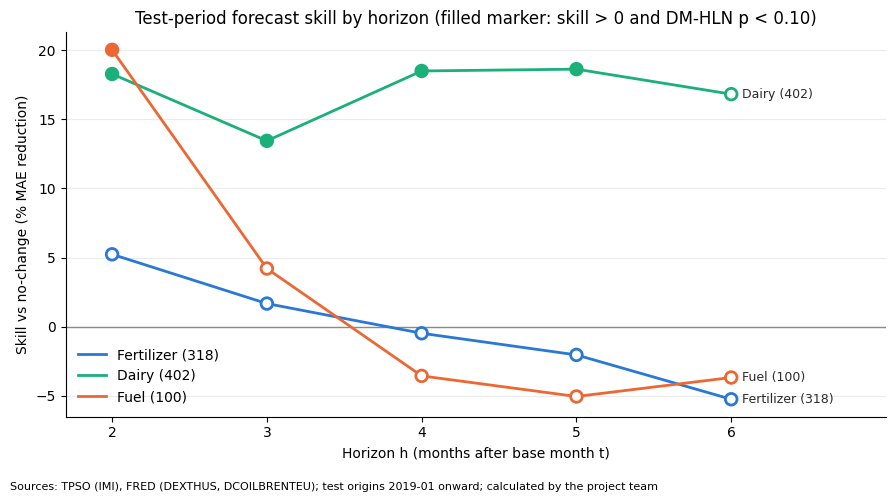

In [7]:
rq4 = pd.DataFrame([{**comparison('RQ4a best vs no_change', g, h, BEST[(g, h)], 'no_change/none')}
                    for g in ['100', '318', '402'] for h in sorted(test.horizon.unique())])
rq4['skill'] = 1 - rq4.MAE_1 / rq4.MAE_2
rq4['passes'] = (rq4.skill > 0) & (rq4.p_value < ALPHA_WARN)
rq4.to_csv(METRICS_DIR / '05_rq4_horizon_skill.csv', index=False)
warn_h = {g: (int(rq4[(rq4.commodity_code == g) & rq4.passes].horizon.max()) if rq4[(rq4.commodity_code == g) & rq4.passes].size else None)
          for g in ['100', '318', '402']}
display(rq4[['commodity_code', 'horizon', 'model_1', 'MAE_1', 'MAE_2', 'skill', 'p_value', 'passes']].round(3))
print('horizon ที่ยาวที่สุดที่ยังเตือนได้:', warn_h)

fig, axis = plt.subplots(figsize=(9, 5))
axis.axhline(0, color=MUTED, linewidth=1)
for g in ['318', '402', '100']:
    frame = rq4[rq4.commodity_code == g]
    axis.plot(frame.horizon, 100 * frame.skill, color=COLORS[g], linewidth=2, label=GROUP_LABEL[g])
    axis.scatter(frame.horizon, 100 * frame.skill, s=70, edgecolors=COLORS[g], zorder=3,
                 facecolors=[COLORS[g] if p else 'white' for p in frame.passes], linewidths=2)
    last = frame.iloc[-1]
    axis.annotate(GROUP_LABEL[g], (last.horizon, 100 * last.skill), xytext=(8, 0), textcoords='offset points',
                  va='center', fontsize=9, color=INK)
axis.set_xticks(sorted(rq4.horizon.unique()))
axis.set_xlim(1.7, 7.0)
axis.set_xlabel('Horizon h (months after base month t)')
axis.set_ylabel('Skill vs no-change (% MAE reduction)')
axis.set_title('Test-period forecast skill by horizon (filled marker: skill > 0 and DM-HLN p < 0.10)')
axis.grid(axis='y', alpha=0.25)
for side in ('top', 'right'): axis.spines[side].set_visible(False)
axis.legend(frameon=False, loc='lower left')
fig.text(0.01, 0.01, 'Sources: TPSO (IMI), FRED (DEXTHUS, DCOILBRENTEU); test origins 2019-01 onward; calculated by the project team', fontsize=8)
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(FIGURES_DIR / '05_skill_by_horizon.png', dpi=180, bbox_inches='tight')
plt.show()

### 5.3 Sensitivity: ตัด origin ที่การเลือกโมเดลใช้ validation label ที่ยังไม่เผยแพร่

**ที่มา:** การตรวจทาน (`reports/review/REVIEW.md`) พบว่า alpha ของ Ridge และโมเดลที่ดีที่สุดเลือกจาก validation ครบถึง t = 2018-12
- target ของ validation แถวสุดท้ายจะเผยแพร่วันที่ 15 ของเดือน (2018-12 + h + 2)
- test origin ช่วงแรกกลุ่มละ h−1 จุดต่อ horizon (รวม 45 จาก 1,320 origins) จึงใช้ข้อมูลที่ ณ วันนั้นยังไม่มีในการเลือกโมเดล

**วิธีตรวจ:** คงผลหลักที่กำหนดไว้ล่วงหน้าไว้ตามเดิม แล้วคำนวณซ้ำโดยตัด origin ที่ `forecast_origin` ก่อนวันเผยแพร่ target ของ validation แถวสุดท้าย (embargo) กติกานี้กำหนดจากเวลา ไม่ได้เลือกจากผล จึงไม่เปลี่ยนโมเดล alpha หรือ threshold

In [8]:
TEST_START = pd.Timestamp('2019-01-01')
modeling_avail = pd.read_csv(ROOT / 'data/processed/modeling_table.csv', dtype={'commodity_code': str},
                             parse_dates=['month_ce', 'target_available_date'])
last_val = modeling_avail[modeling_avail.month_ce == TEST_START - pd.DateOffset(months=1)]
embargo_until = {(r.commodity_code, int(r.horizon)): r.target_available_date for r in last_val.itertuples()}
test_e = test[[o >= embargo_until[(g, int(h))] for g, h, o in zip(test.commodity_code, test.horizon, test.forecast_origin)]]
dropped = (test.groupby(['commodity_code', 'horizon']).month_ce.nunique() - test_e.groupby(['commodity_code', 'horizon']).month_ce.nunique())
assert (dropped.reset_index().pipe(lambda d: d.month_ce == d.horizon - 1)).all(), 'จำนวน origin ที่ตัดต้องเท่ากับ h−1'

def errors_e(g, h, s):
    return test_e[(test_e.commodity_code == g) & (test_e.horizon == h) & (test_e.series == s)].sort_values('month_ce').error.values

emb_rows = []
for g in MAIN_GROUPS + [SANITY_GROUP]:
    for label, s1, s2 in COMPARISONS:
        s1 = s1 or BEST[(g, PRIMARY_H)]
        e1, e2 = errors_e(g, PRIMARY_H, s1), errors_e(g, PRIMARY_H, s2)
        emb_rows.append({'comparison': label, 'commodity_code': g, 'model_1': s1, 'model_2': s2,
                         'MAE_1': np.abs(e1).mean(), 'MAE_2': np.abs(e2).mean(), **dm_hln(e1, e2, PRIMARY_H)})
dm_emb = pd.DataFrame(emb_rows)
fam = dm_emb.commodity_code.isin(MAIN_GROUPS)
dm_emb['p_holm'] = np.nan
dm_emb.loc[fam, 'p_holm'] = multipletests(dm_emb.loc[fam, 'p_value'], method='holm')[1]
dm_emb = dm_emb.merge(dm_main[['comparison', 'commodity_code', 'p_value', 'p_holm']], on=['comparison', 'commodity_code'], suffixes=('', '_main'))
dm_emb.to_csv(METRICS_DIR / '05_embargo_dm_comparisons.csv', index=False)

rq4_e = []
for g in ['100', '318', '402']:
    for h in sorted(test.horizon.unique()):
        e1, e2 = errors_e(g, h, BEST[(g, h)]), errors_e(g, h, 'no_change/none')
        r = dm_hln(e1, e2, h)
        rq4_e.append({'commodity_code': g, 'horizon': h, 'n': r['n'], 'skill': 1 - np.abs(e1).mean() / np.abs(e2).mean(),
                      'p_value': r['p_value']})
rq4_e = pd.DataFrame(rq4_e)
rq4_e['passes'] = (rq4_e.skill > 0) & (rq4_e.p_value < ALPHA_WARN)
rq4_e = rq4_e.merge(rq4[['commodity_code', 'horizon', 'passes']], on=['commodity_code', 'horizon'], suffixes=('', '_main'))
rq4_e.to_csv(METRICS_DIR / '05_embargo_rq4_horizon_skill.csv', index=False)
alerts_e = pd.DataFrame([{'commodity_code': g, 'series': BEST[(g, PRIMARY_H)],
                          **alert_scores(test_e[(test_e.commodity_code == g) & (test_e.horizon == PRIMARY_H) & (test_e.series == BEST[(g, PRIMARY_H)])])}
                         for g in MAIN_GROUPS])
alerts_e.to_csv(METRICS_DIR / '05_embargo_alert_metrics.csv', index=False)

display(dm_emb[['comparison', 'commodity_code', 'n', 'MAE_1', 'MAE_2', 'p_value', 'p_holm', 'p_value_main', 'p_holm_main']].round(3))
display(rq4_e.round(3))
display(alerts_e.round(3))
same_main = bool(((dm_emb.loc[fam, 'p_holm'] < 0.05) == (dm_emb.loc[fam, 'p_holm_main'] < 0.05)).all())
same_rq4 = bool((rq4_e.passes == rq4_e.passes_main).all())
print(f'ข้อสรุปการเปรียบเทียบหลักเหมือนเดิม: {same_main}; ผลเกณฑ์ "ยังเตือนได้" เหมือนเดิมทุก h: {same_rq4}')

,comparison,commodity_code,n,MAE_1,MAE_2,p_value,p_holm,p_value_main,p_holm_main
0,C1 ridge/3 vs ridge/1,318,87,6.486,6.503,0.959,1.000,0.941,1.000
1,C2 best(validation) vs no_change,318,87,6.486,6.594,0.805,1.000,0.798,1.000
2,C3 ridge/3 vs ridge/3-noRecent,318,87,6.486,6.646,0.231,0.925,0.249,0.996
3,C1 ridge/3 vs ridge/1,402,87,2.242,2.096,0.069,0.404,0.069,0.379
4,C2 best(validation) vs no_change,402,87,2.243,2.587,0.067,0.404,0.063,0.379
5,C3 ridge/3 vs ridge/3-noRecent,402,87,2.242,2.244,0.925,1.000,0.920,1.000
6,C1 ridge/3 vs ridge/1,100,87,10.056,10.505,0.612,NaN,0.545,NaN
7,C2 best(validation) vs no_change,100,87,10.056,10.388,0.735,NaN,0.646,NaN
8,C3 ridge/3 vs ridge/3-noRecent,100,87,10.056,10.509,0.607,NaN,0.541,NaN


,commodity_code,horizon,n,skill,p_value,passes,passes_main
0,100,2,89,0.193,0.027,True,True
1,100,3,87,0.032,0.735,False,False
2,100,4,85,-0.025,0.782,False,False
3,100,5,83,-0.035,0.665,False,False
4,100,6,81,-0.019,0.840,False,False
5,318,2,89,0.051,0.424,False,False
6,318,3,87,0.016,0.805,False,False
7,318,4,85,-0.005,0.952,False,False
8,318,5,83,-0.012,0.860,False,False
9,318,6,81,-0.038,0.612,False,False


,commodity_code,series,n,events,prevalence,alerts,TP,FP,FN,TN,precision,recall,F1
0,318,ridge/3,87,34,0.391,24,13,11,21,42,0.542,0.382,0.448
1,402,ridge/3-cutoff24,87,29,0.333,0,0,0,29,58,NaN,0.000,0.000


ข้อสรุปการเปรียบเทียบหลักเหมือนเดิม: True; ผลเกณฑ์ "ยังเตือนได้" เหมือนเดิมทุก h: True


## 6. กราฟ Actual vs Predicted และ threshold

กราฟแรกแสดงค่าจริงเทียบค่าทำนายของโมเดลที่ดีที่สุดจาก validation ที่ h=3 ช่วง test ส่วนกราฟที่สองแสดง threshold ของ High Risk ราย origin ตาม Scope หัวข้อ 14

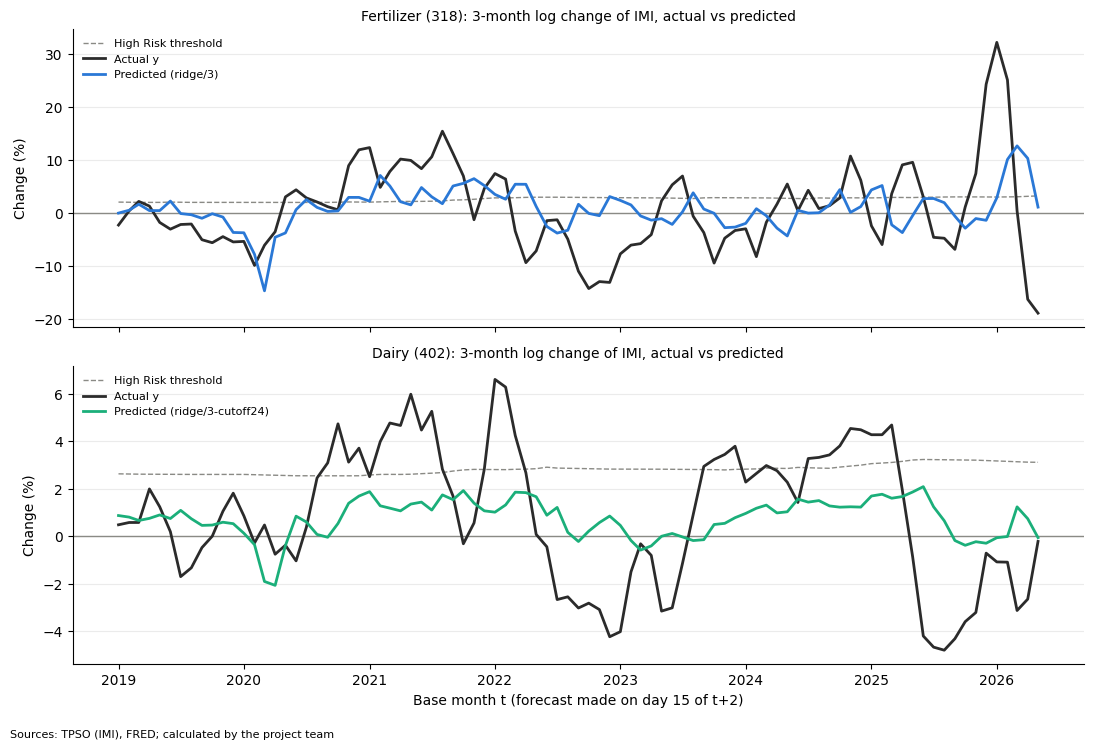

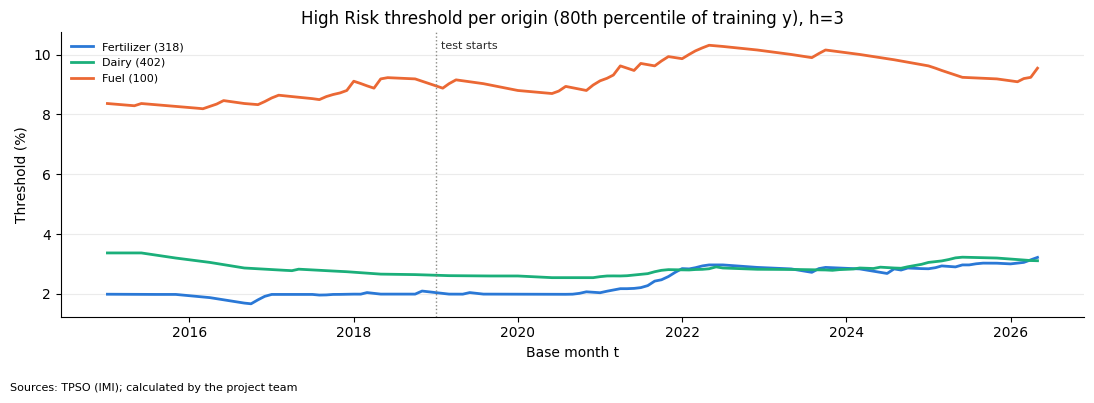

In [9]:
fig, axes = plt.subplots(len(MAIN_GROUPS), 1, figsize=(11, 7.5), sharex=True)
for axis, g in zip(axes, MAIN_GROUPS):
    frame = test[(test.commodity_code == g) & (test.horizon == PRIMARY_H) & (test.series == BEST[(g, PRIMARY_H)])]
    axis.axhline(0, color=MUTED, linewidth=1)
    axis.plot(frame.month_ce, frame.high_risk_threshold, color=MUTED, linewidth=1, linestyle='--', label='High Risk threshold')
    axis.plot(frame.month_ce, frame.y_true, color=INK, linewidth=2, label='Actual y')
    axis.plot(frame.month_ce, frame.y_pred, color=COLORS[g], linewidth=2, label=f'Predicted ({BEST[(g, PRIMARY_H)]})')
    axis.set_title(f'{GROUP_LABEL[g]}: 3-month log change of IMI, actual vs predicted', fontsize=10)
    axis.set_ylabel('Change (%)')
    axis.grid(axis='y', alpha=0.25)
    for side in ('top', 'right'): axis.spines[side].set_visible(False)
    axis.legend(frameon=False, fontsize=8, loc='upper left')
axes[-1].set_xlabel('Base month t (forecast made on day 15 of t+2)')
fig.text(0.01, 0.01, 'Sources: TPSO (IMI), FRED; calculated by the project team', fontsize=8)
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIGURES_DIR / '05_actual_vs_predicted_h3.png', dpi=180, bbox_inches='tight')
plt.show()

origins = pd.read_csv(METRICS_DIR / '04_origins.csv', dtype={'commodity_code': str}, parse_dates=['month_ce'])
fig, axis = plt.subplots(figsize=(11, 4))
for g in ['318', '402', '100']:
    frame = origins[(origins.commodity_code == g) & (origins.horizon == PRIMARY_H)]
    axis.plot(frame.month_ce, frame.high_risk_threshold, color=COLORS[g], linewidth=2, label=GROUP_LABEL[g])
axis.axvline(pd.Timestamp('2019-01-01'), color=MUTED, linewidth=1, linestyle=':')
axis.annotate('test starts', (pd.Timestamp('2019-01-01'), axis.get_ylim()[1]), xytext=(4, -12), textcoords='offset points', fontsize=8, color=INK)
axis.set_title('High Risk threshold per origin (80th percentile of training y), h=3')
axis.set_xlabel('Base month t')
axis.set_ylabel('Threshold (%)')
axis.grid(axis='y', alpha=0.25)
for side in ('top', 'right'): axis.spines[side].set_visible(False)
axis.legend(frameon=False, fontsize=8)
fig.text(0.01, 0.01, 'Sources: TPSO (IMI); calculated by the project team', fontsize=8)
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(FIGURES_DIR / '05_high_risk_threshold_h3.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. คำตอบ Research Questions

ข้อความด้านล่างสร้างจากตัวเลขที่คำนวณใน notebook นี้ เกณฑ์นัยสำคัญของการเปรียบเทียบหลักคือ Holm-adjusted p < 0.05

In [10]:
def row(label, g):
    return dm_main[(dm_main.comparison == label) & (dm_main.commodity_code == g)].iloc[0]

def verdict(r, better, worse):
    sig = r.p_holm < 0.05 if not np.isnan(r.p_holm) else r.p_value < 0.05
    direction = better if r.mean_loss_diff < 0 else worse
    return f"{direction} (MAE {r.MAE_1:.3f} เทียบ {r.MAE_2:.3f}, เปลี่ยน {r.mae_change_pct:+.1f}%, DM-HLN p = {r.p_value:.3f}, Holm p = {r.p_holm:.3f}; {'มีนัยสำคัญ' if sig else 'ไม่มีนัยสำคัญ'})"

lines = ['**RQ1–RQ2: ข้อมูลภายนอกช่วยหรือไม่ และต่างกันระหว่างกลุ่มหรือไม่ (Ridge ชุด 3 เทียบชุด 1, h=3)**']
for g in MAIN_GROUPS:
    lines.append(f"- {GROUP_LABEL[g]}: ชุด 3 " + verdict(row('C1 ridge/3 vs ridge/1', g), 'แม่นกว่าชุด 1', 'แม่นน้อยกว่าชุด 1'))
lines.append('\n**การใช้งานจริง: โมเดลที่ดีที่สุดจาก validation เทียบ No-change (h=3)**')
for g in MAIN_GROUPS:
    r = row('C2 best(validation) vs no_change', g)
    lines.append(f"- {GROUP_LABEL[g]}: {r.model_1} " + verdict(r, 'แม่นกว่า No-change', 'แม่นน้อยกว่า No-change'))
lines.append('\n**RQ3: ช่วยเพราะข้อมูลออกเร็วกว่า IMI หรือไม่ (ชุด 3 เทียบ 3-noRecent, h=3)**')
for g in MAIN_GROUPS:
    lines.append(f"- {GROUP_LABEL[g]}: ชุด 3 " + verdict(row('C3 ridge/3 vs ridge/3-noRecent', g), 'แม่นกว่าเมื่อมีข้อมูลเดือน t+1', 'ไม่ได้แม่นขึ้นเมื่อมีข้อมูลเดือน t+1'))
lines.append('\n**RQ4(ก): เตือนได้ไกลแค่ไหน (เชิงสำรวจ)**')
for g in ['318', '402']:
    frame = rq4[rq4.commodity_code == g]
    lines.append(f"- {GROUP_LABEL[g]}: skill ตาม h=2–6 = " + ', '.join(f"{100 * s:+.1f}%" for s in frame.skill)
                 + f"; horizon ที่ยาวที่สุดที่ผ่านเกณฑ์ = {warn_h[g] if warn_h[g] else 'ไม่มี'}")
r = row('C1 ridge/3 vs ridge/1', SANITY_GROUP)
lines.append(f"\n**Sanity check {GROUP_LABEL[SANITY_GROUP]}:** ชุด 3 MAE {r.MAE_1:.3f} เทียบชุด 1 {r.MAE_2:.3f} (DM-HLN p = {r.p_value:.3f})")
lines.append(f"\n**Sensitivity (embargo, ตัด {int(dropped.sum())} origins):** ข้อสรุปการเปรียบเทียบหลัก{'เหมือนเดิม' if same_main else 'เปลี่ยน'} และเกณฑ์ยังเตือนได้{'เหมือนเดิมทุก horizon' if same_rq4 else 'เปลี่ยนในบาง horizon'} (Holm p ต่ำสุด {dm_emb.loc[fam, 'p_holm'].min():.3f})")
lines.append('\nRQ4(ข) ดูผล pass-through ใน notebook 02 หัวข้อ 6 ข้อสรุปเชิงตีความและข้อจำกัดเขียนในรายงานโดยอ้างตัวเลขจากตารางใน logs/metrics')
display(Markdown('\n'.join(lines)))

**RQ1–RQ2: ข้อมูลภายนอกช่วยหรือไม่ และต่างกันระหว่างกลุ่มหรือไม่ (Ridge ชุด 3 เทียบชุด 1, h=3)**
- Fertilizer (318): ชุด 3 แม่นกว่าชุด 1 (MAE 6.367 เทียบ 6.390, เปลี่ยน -0.4%, DM-HLN p = 0.941, Holm p = 1.000; ไม่มีนัยสำคัญ)
- Dairy (402): ชุด 3 แม่นน้อยกว่าชุด 1 (MAE 2.199 เทียบ 2.055, เปลี่ยน +7.0%, DM-HLN p = 0.069, Holm p = 0.379; ไม่มีนัยสำคัญ)

**การใช้งานจริง: โมเดลที่ดีที่สุดจาก validation เทียบ No-change (h=3)**
- Fertilizer (318): ridge/3 แม่นกว่า No-change (MAE 6.367 เทียบ 6.476, เปลี่ยน -1.7%, DM-HLN p = 0.798, Holm p = 1.000; ไม่มีนัยสำคัญ)
- Dairy (402): ridge/3-cutoff24 แม่นกว่า No-change (MAE 2.199 เทียบ 2.541, เปลี่ยน -13.4%, DM-HLN p = 0.063, Holm p = 0.379; ไม่มีนัยสำคัญ)

**RQ3: ช่วยเพราะข้อมูลออกเร็วกว่า IMI หรือไม่ (ชุด 3 เทียบ 3-noRecent, h=3)**
- Fertilizer (318): ชุด 3 แม่นกว่าเมื่อมีข้อมูลเดือน t+1 (MAE 6.367 เทียบ 6.517, เปลี่ยน -2.3%, DM-HLN p = 0.249, Holm p = 0.996; ไม่มีนัยสำคัญ)
- Dairy (402): ชุด 3 แม่นกว่าเมื่อมีข้อมูลเดือน t+1 (MAE 2.199 เทียบ 2.201, เปลี่ยน -0.1%, DM-HLN p = 0.920, Holm p = 1.000; ไม่มีนัยสำคัญ)

**RQ4(ก): เตือนได้ไกลแค่ไหน (เชิงสำรวจ)**
- Fertilizer (318): skill ตาม h=2–6 = +5.2%, +1.7%, -0.5%, -2.0%, -5.2%; horizon ที่ยาวที่สุดที่ผ่านเกณฑ์ = ไม่มี
- Dairy (402): skill ตาม h=2–6 = +18.3%, +13.4%, +18.5%, +18.6%, +16.8%; horizon ที่ยาวที่สุดที่ผ่านเกณฑ์ = 5

**Sanity check Fuel (100):** ชุด 3 MAE 9.900 เทียบชุด 1 10.419 (DM-HLN p = 0.545)

**Sensitivity (embargo, ตัด 45 origins):** ข้อสรุปการเปรียบเทียบหลักเหมือนเดิม และเกณฑ์ยังเตือนได้เหมือนเดิมทุก horizon (Holm p ต่ำสุด 0.404)

RQ4(ข) ดูผล pass-through ใน notebook 02 หัวข้อ 6 ข้อสรุปเชิงตีความและข้อจำกัดเขียนในรายงานโดยอ้างตัวเลขจากตารางใน logs/metrics

In [11]:
log_path = ROOT / 'logs/process_log.md'
log = log_path.read_text(encoding='utf-8')
marker = 'ขั้นตอน: 05 Evaluation'
if marker not in log:
    def short(label, g):
        r = row(label, g)
        return f"{GROUP_LABEL[g]} MAE {r.MAE_1:.3f} เทียบ {r.MAE_2:.3f} (p {r.p_value:.3f}, Holm {r.p_holm:.3f})"
    alert_txt = '; '.join(
        f"{GROUP_LABEL[g]} {BEST[(g, PRIMARY_H)]}: precision {a.precision:.2f}, recall {a.recall:.2f}, F1 {a.F1:.2f}, events {a.events}/{a.n}"
        for g in MAIN_GROUPS for a in [alerts[(alerts.commodity_code == g) & (alerts.series == BEST[(g, PRIMARY_H)])].iloc[0]])
    entry = f"""

## [2026-10-05] {marker}
**สิ่งที่ทำ:** เลือกโมเดลที่ดีที่สุดจาก validation MAE แล้วประเมินช่วง test (t ตั้งแต่ 2019-01) ด้วย MAE, RMSE และ DA ทดสอบการเปรียบเทียบหลัก 3 ข้อที่ h=3 ด้วย DM-HLN พร้อม Holm ประเมิน alert layer, sensitivity ของ cutoff วันที่ 24 และเส้นความแม่นตาม horizon

**ผลที่ได้:**
- C1 ชุด 3 เทียบชุด 1: {short('C1 ridge/3 vs ridge/1', '318')}; {short('C1 ridge/3 vs ridge/1', '402')}
- C2 best เทียบ No-change: {short('C2 best(validation) vs no_change', '318')}; {short('C2 best(validation) vs no_change', '402')}
- C3 ชุด 3 เทียบ 3-noRecent: {short('C3 ridge/3 vs ridge/3-noRecent', '318')}; {short('C3 ridge/3 vs ridge/3-noRecent', '402')}
- Alert h=3: {alert_txt}
- RQ4(ก) horizon ที่ยาวที่สุดที่ผ่านเกณฑ์: {warn_h}
- ไฟล์: logs/metrics/05_*.csv และ reports/figures/05_*.png

**สิ่งที่พบ / ปัญหา:** ดูการตีความใน notebook 05 หัวข้อ 7 ช่วง test ครอบคลุมช่วงโควิดและราคาปุ๋ยผันผวนปี 2021–22 และ target ของ h=3 ซ้อนกัน ทำให้กำลังของ DM test ต่ำ

**การตัดสินใจและเหตุผล:** รายงานผลตามการเปรียบเทียบหลักที่กำหนดไว้ล่วงหน้า ไม่เปลี่ยนโมเดล feature หรือ threshold หลังเห็นผล test

**ขั้นต่อไป:** 06 Deployment (dashboard) และเขียนรายงาน CRISP-DM
"""
    log_path.write_text(log.rstrip() + entry + '\n', encoding='utf-8')
    print('บันทึกผลลง logs/process_log.md แล้ว')
else:
    print('มีรายการ 05 Evaluation ใน process log แล้ว จึงไม่บันทึกซ้ำ')

มีรายการ 05 Evaluation ใน process log แล้ว จึงไม่บันทึกซ้ำ


In [12]:
marker_e = 'ขั้นตอน: 05 Evaluation (sensitivity embargo จากการตรวจทาน)'
log = log_path.read_text(encoding='utf-8')
if marker_e not in log:
    entry = f"""

## [2026-10-05] {marker_e}
**สิ่งที่ทำ:** เพิ่มหัวข้อ 5.3 ใน notebook 05 ตามรายงานตรวจทาน (reports/review/REVIEW.md) ซึ่งพบว่าการเลือก alpha และโมเดลใช้ validation label ถึง t = 2018-12 ที่ยังไม่เผยแพร่ ณ test origin ช่วงแรก จึงคำนวณผลซ้ำโดยตัด origin ก่อนวันเผยแพร่ target ของ validation แถวสุดท้าย (กลุ่มละ h−1 origins ต่อ horizon รวม {int(dropped.sum())} จาก {test.groupby(['commodity_code', 'horizon']).month_ce.nunique().sum()} origins)

**ผลที่ได้:**
- การเปรียบเทียบหลักหลัง embargo: Holm p ต่ำสุด {dm_emb.loc[fam, 'p_holm'].min():.3f} (ผลหลัก {dm_emb.loc[fam, 'p_holm_main'].min():.3f}) ข้อสรุป{'เหมือนเดิม' if same_main else 'เปลี่ยน'}
- เกณฑ์ "ยังเตือนได้" {'เหมือนเดิมทุกกลุ่มและ horizon' if same_rq4 else 'เปลี่ยนในบาง horizon'}
- ไฟล์: logs/metrics/05_embargo_*.csv

**สิ่งที่พบ / ปัญหา:** checkpoint เดิมตรวจ leakage ในระดับ training rows แต่ไม่ได้ตรวจเวลาของข้อมูลที่ใช้เลือกโมเดล

**การตัดสินใจและเหตุผล:** คงผลหลักตามการออกแบบที่กำหนดไว้ก่อนเปิด test และรายงาน embargo เป็น sensitivity เพราะกติกา embargo กำหนดจากเวลา ไม่ได้เลือกจากผล ถ้าทำรอบใหม่ ควรเลือกโมเดลจาก validation label ที่เผยแพร่แล้ว ณ test origin แรกเท่านั้น

**ขั้นต่อไป:** ปรับข้อความ pass-through และ replay guard ตามข้อเสนอของการตรวจทาน
"""
    log_path.write_text(log.rstrip() + entry + '\n', encoding='utf-8')
    print('บันทึกผล sensitivity ลง logs/process_log.md แล้ว')
else:
    print('มีรายการ sensitivity embargo ใน process log แล้ว จึงไม่บันทึกซ้ำ')

บันทึกผล sensitivity ลง logs/process_log.md แล้ว
